In [1]:
import neo
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.fft import fft, fftfreq
from scipy import signal
import pywt

In [2]:
path_plx = "../data/22q_del_WT_raw_data/241117-1-1_ID243(WT)_M1 (1mm, 1mm, 0.7mm).plx"

plx = neo.io.PlexonIO(filename=path_plx)

Parsing signal channels: 100%|██████████| 128/128 [00:00<?, ?it/s]
Parsing spike channels: 0it [00:00, ?it/s]
Parsing event channels: 100%|██████████| 43/43 [00:00<?, ?it/s]


In [3]:
# read data
data = plx.read()

In [4]:
# analogsignals
# 0: AI, LFP?, Noise?
# 1: LFP
# 2: spikes
for analogsignals in data[0].segments[0].analogsignals:
    display(analogsignals)

AnalogSignal with 2 channels of length 311444; units dimensionless; datatype float32
name: 'AI-Auxiliary Input'
annotations: {'stream_id': 'AI'}
sampling rate: 1000.0 Hz
time: 0.0 s to 311.444 s

AnalogSignal with 16 channels of length 311464; units dimensionless; datatype float32
name: 'FPl-Low Pass Filtered'
annotations: {'stream_id': 'FP'}
sampling rate: 1000.0 Hz
time: 0.0 s to 311.464 s

AnalogSignal with 16 channels of length 12458544; units dimensionless; datatype float32
name: 'SPKC'
annotations: {'stream_id': 'SPKC'}
sampling rate: 40000.0 Hz
time: 0.0 s to 311.4636 s

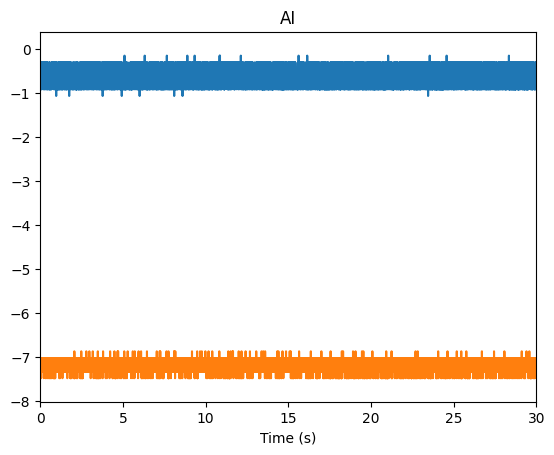

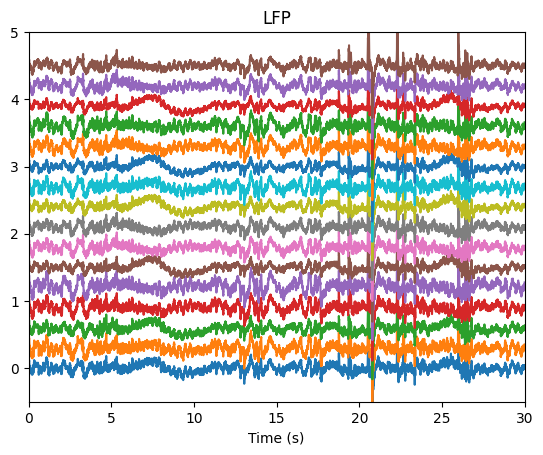

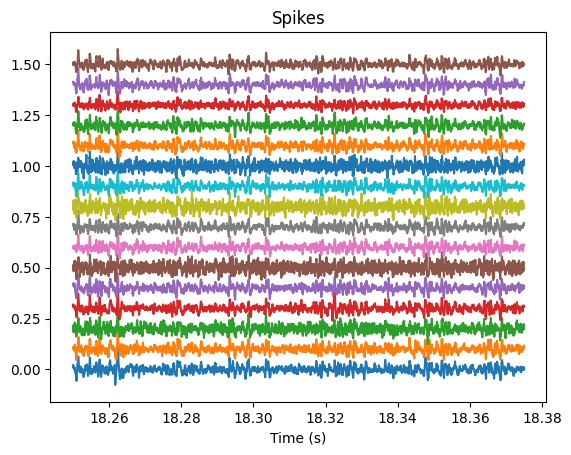

In [5]:
# get spikes, LFP, AI?
ai = data[0].segments[0].analogsignals[0]
lfp = data[0].segments[0].analogsignals[1]
spikes = data[0].segments[0].analogsignals[2]

# plot AI
plt.figure()
for i, ai_channel in enumerate(ai.T):
    plt.plot(ai.times, ai_channel)
plt.title("AI")
plt.xlabel("Time (s)")
plt.xlim(0, 30)
plt.show()

# plot LFP
plt.figure()
for i, lfp_channel in enumerate(lfp.T):
    plt.plot(lfp.times, lfp_channel + i * 0.3)
plt.title("LFP")
plt.xlabel("Time (s)")
plt.xlim(0, 30)
plt.ylim(-0.5, 5.0)
plt.show()

# plot spikes
idx_start = 730000
idx_length = 5000

plt.figure()
for i, spikes_channel in enumerate(spikes.T):
    plt.plot(spikes.times[idx_start:idx_start+idx_length], spikes_channel[idx_start:idx_start+idx_length] + i * 0.1)
plt.title("Spikes")
plt.xlabel("Time (s)")
plt.show()

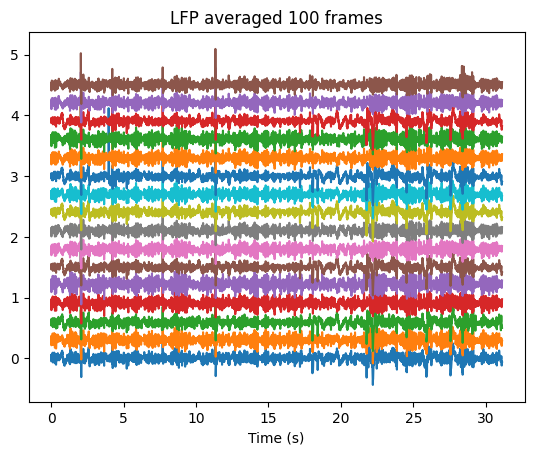

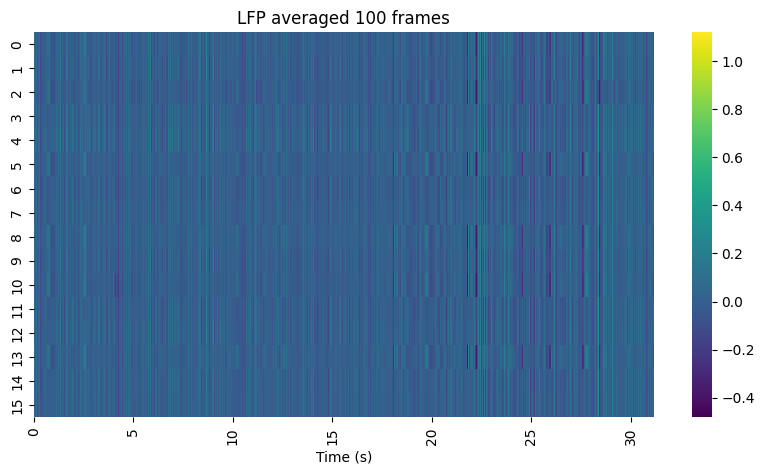

In [6]:
# 100 frame average
mean_duration = 100

lfp_mean = []

for i in range(len(lfp) // mean_duration):
    lfp_mean.append(np.mean(lfp[i*mean_duration:(i+1)*mean_duration], axis=0))

lfp_mean = np.array(lfp_mean)

# plot LFP
plt.figure()
for i, lfp_channel in enumerate(lfp_mean.T):
    plt.plot(lfp_channel + i * 0.3)
plt.title(f"LFP averaged {mean_duration} frames")
plt.xlabel("Time (s)")
plt.xticks(np.arange(0, 35*mean_duration, 5*mean_duration), np.arange(0, 35, 5))
plt.show()

# heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(lfp_mean.T, cmap="viridis")
plt.title(f"LFP averaged {mean_duration} frames")
plt.xlabel("Time (s)")
plt.xticks(np.arange(0, 35*mean_duration, 5*mean_duration), np.arange(0, 35, 5))
plt.show()

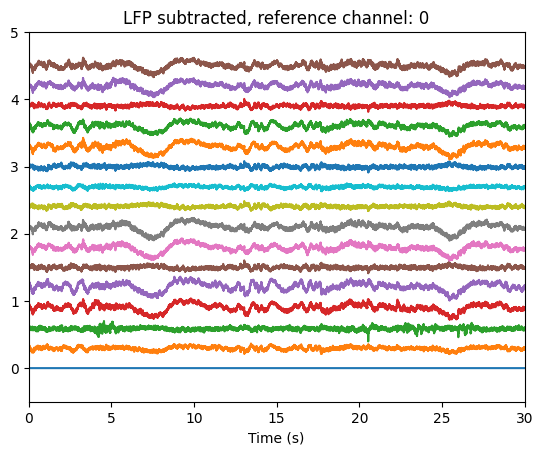

In [7]:
# substract with reference channel
channel_ref = 0

lfp_subtracted = lfp - lfp[:, channel_ref]

# plot LFP
plt.figure()
for i, lfp_channel in enumerate(lfp_subtracted.T):
    plt.plot(lfp.times, lfp_channel + i * 0.3)
plt.title(f"LFP subtracted, reference channel: {channel_ref}")
plt.xlabel("Time (s)")
plt.xlim(0, 30)
plt.ylim(-0.5, 5.0)
plt.show()

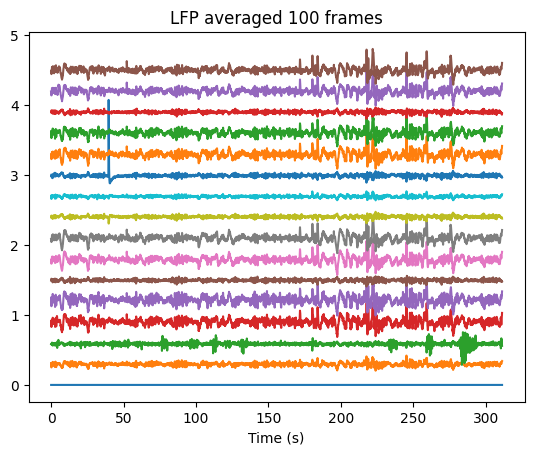

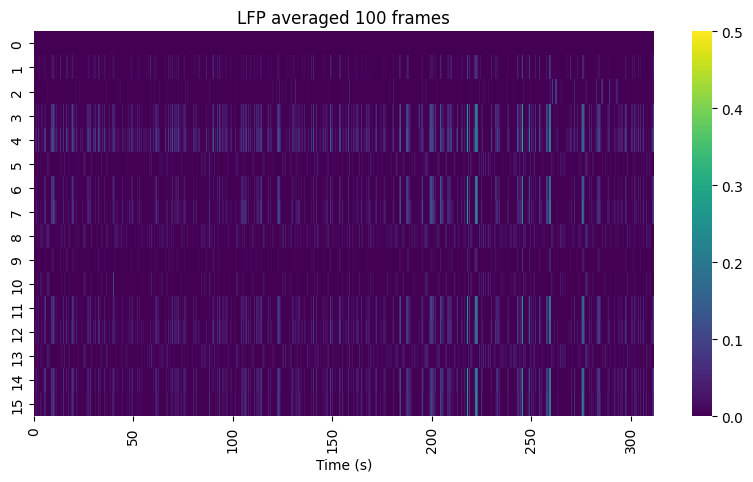

In [8]:
# 100 frame average
mean_duration = 100

lfp_mean = []

for i in range(len(lfp_subtracted) // mean_duration):
    lfp_mean.append(np.mean(lfp_subtracted[i*mean_duration:(i+1)*mean_duration], axis=0))

lfp_mean = np.array(lfp_mean)

# plot LFP
plt.figure()
for i, lfp_channel in enumerate(lfp_mean.T):
    plt.plot(lfp_channel + i * 0.3)
plt.title(f"LFP averaged {mean_duration} frames")
plt.xlabel("Time (s)")
plt.xticks(np.arange(0, 35*mean_duration, 5*mean_duration), np.arange(0, 350, 50))
plt.show()

# heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(lfp_mean.T, cmap="viridis", vmin=0, vmax=0.5)
plt.title(f"LFP averaged {mean_duration} frames")
plt.xlabel("Time (s)")
plt.xticks(np.arange(0, 35*mean_duration, 5*mean_duration), np.arange(0, 350, 50))
plt.show()

## Wavelet transform

In [9]:
fs = 1000
wavelet = "cmor1.5-1.0"

# 解析したい周波数帯
frequencies = np.arange(1, 61, 1)  # 1Hzから60Hzまで1Hz刻み
# 各周波数に対応するスケール値を計算　周波数をそのままは使えない！！！！
scales = pywt.frequency2scale(wavelet, frequencies) * fs
cwtmatr, freq = pywt.cwt(lfp.T, scales, wavelet, sampling_period=1/fs)
cwtmatr = np.abs(cwtmatr)

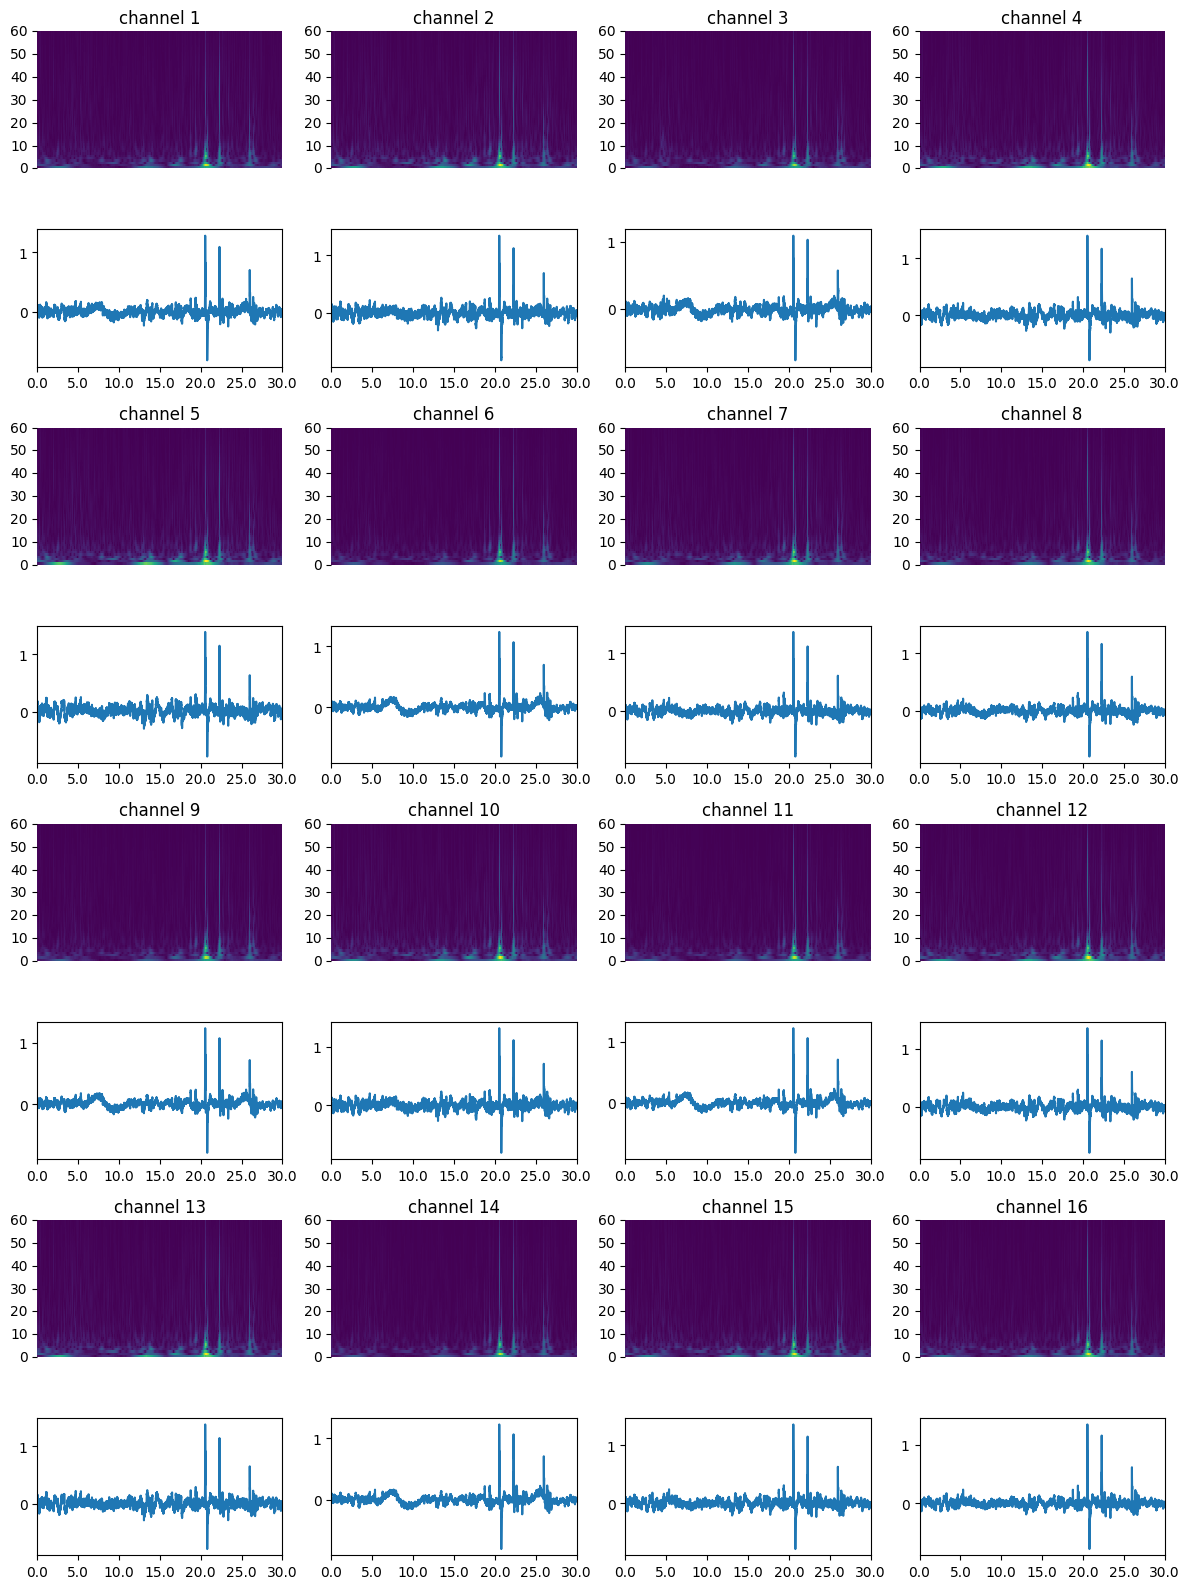

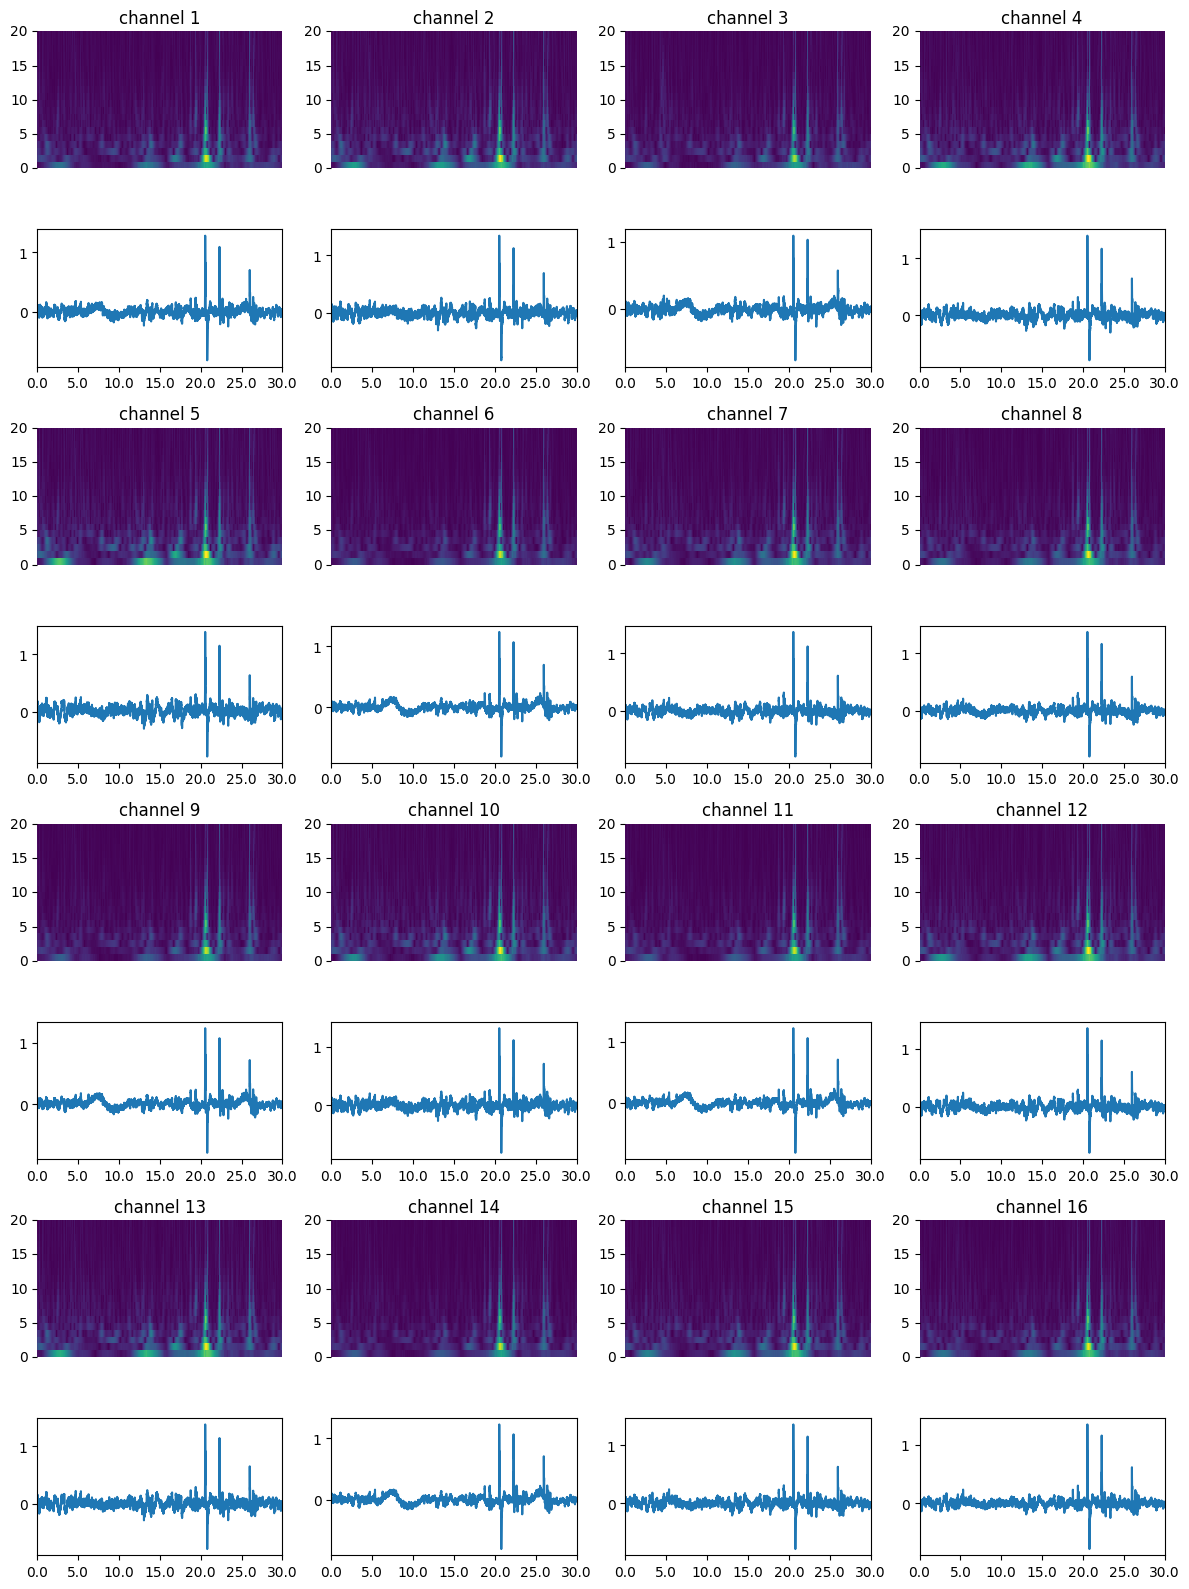

In [14]:
plt.figure(figsize=(12, 16))
t_max = 30000
t_label = 5
vmin, vmax = 0, 2

for channel in range(len(lfp.T)):
    row = channel // 4
    col = channel % 4
    plt.subplot(8, 4, row*8+col+1)
    sns.heatmap(cwtmatr[:, channel, :t_max], cmap="viridis", cbar=False, xticklabels=False, vmin=vmin, vmax=vmax)
    plt.title(f"channel {channel+1}")
    plt.ylim(0, 60)
    plt.yticks(np.arange(0, 61, 10), np.arange(0, 61, 10))

    plt.subplot(8, 4, row*8+col+5)
    plt.plot(lfp[:t_max, channel])
    plt.xlim(0, t_max)
    plt.xticks(np.arange(0, t_max+1, t_label*fs), np.arange(0, t_max/fs+1, t_label))

plt.tight_layout()
plt.show()

# 0~20 Hz
plt.figure(figsize=(12, 16))
t_max = 30000
t_label = 5

for channel in range(len(lfp.T)):
    row = channel // 4
    col = channel % 4
    plt.subplot(8, 4, row*8+col+1)
    sns.heatmap(cwtmatr[:, channel, :t_max], cmap="viridis", cbar=False, xticklabels=False, vmin=vmin, vmax=vmax)
    plt.title(f"channel {channel+1}")
    plt.ylim(0, 20)
    plt.yticks(np.arange(0, 21, 5), np.arange(0, 21, 5))

    plt.subplot(8, 4, row*8+col+5)
    plt.plot(lfp[:t_max, channel])
    plt.xlim(0, t_max)
    plt.xticks(np.arange(0, t_max+1, t_label*fs), np.arange(0, t_max/fs+1, t_label))

plt.tight_layout()
plt.show()

In [15]:
fs = 1000
wavelet = "cmor1.5-1.0"

# 解析したい周波数帯
frequencies = np.arange(1, 61, 1)  # 1Hzから60Hzまで1Hz刻み
# 各周波数に対応するスケール値を計算　周波数をそのままは使えない！！！！
scales = pywt.frequency2scale(wavelet, frequencies) * fs
cwtmatr_subtracted, freq = pywt.cwt(lfp_subtracted.T, scales, wavelet, sampling_period=1/fs)
cwtmatr_subtracted = np.abs(cwtmatr_subtracted)

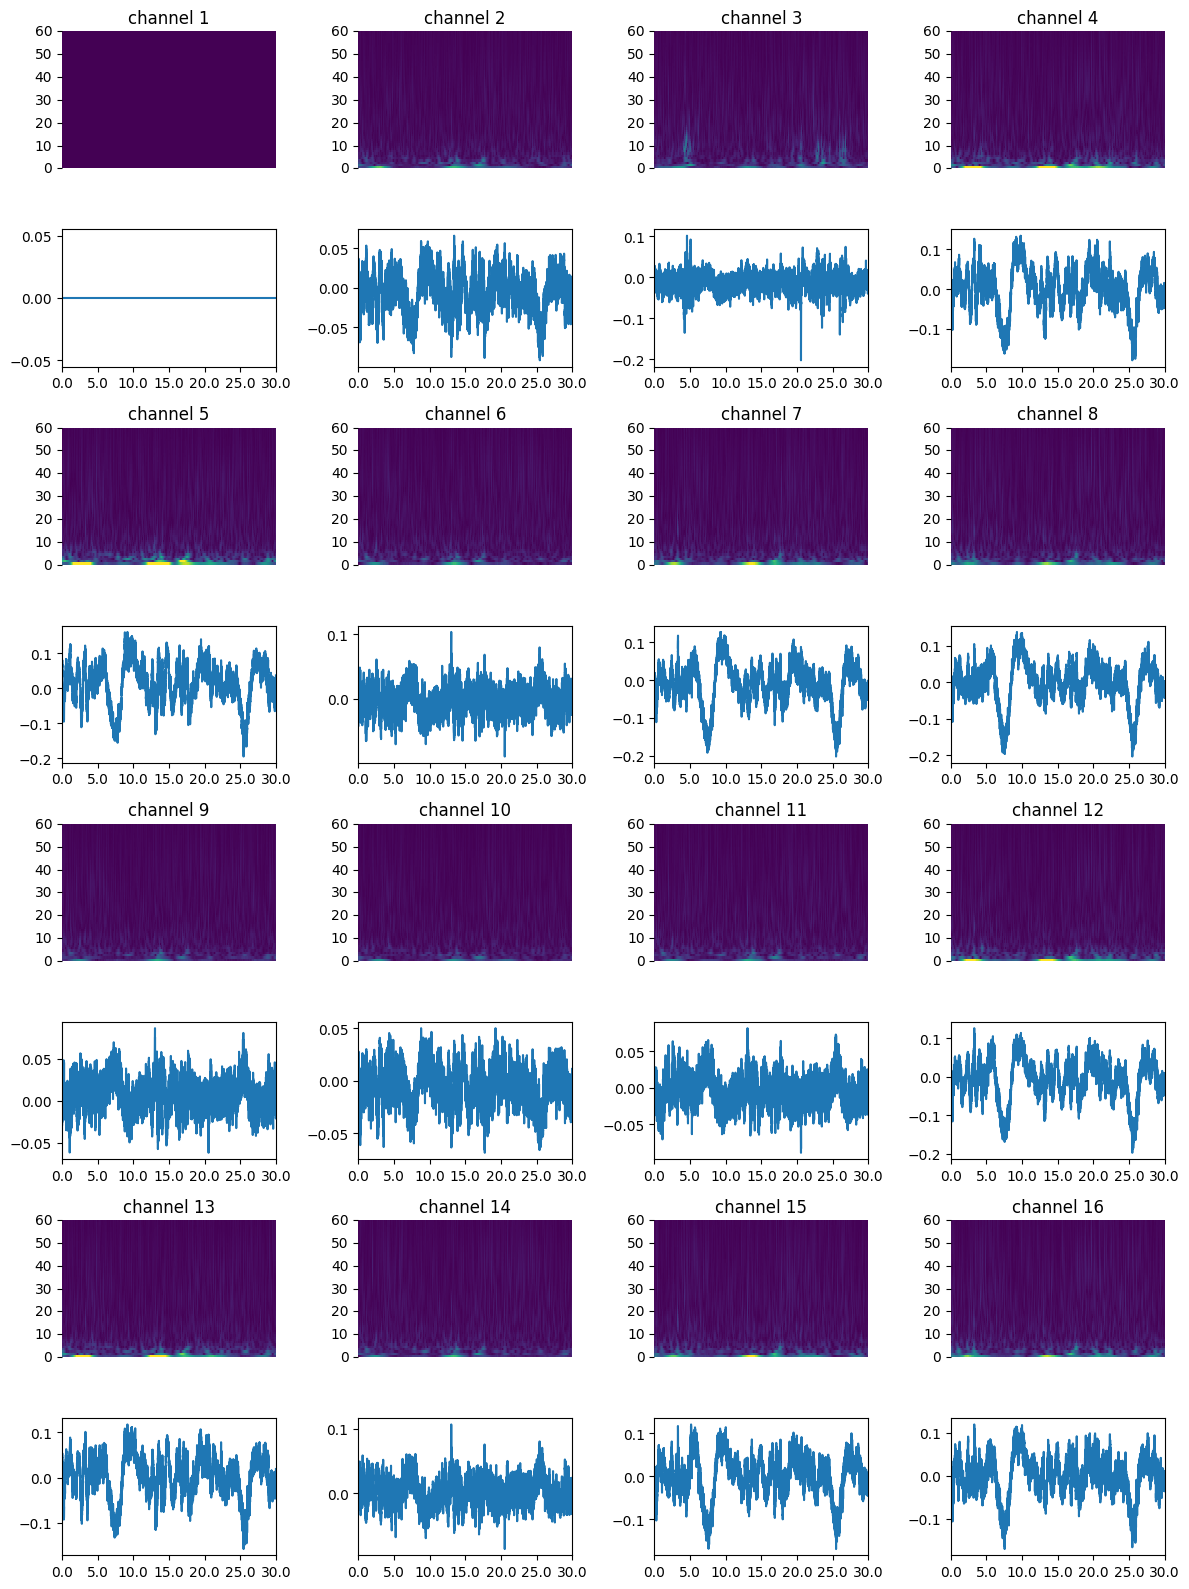

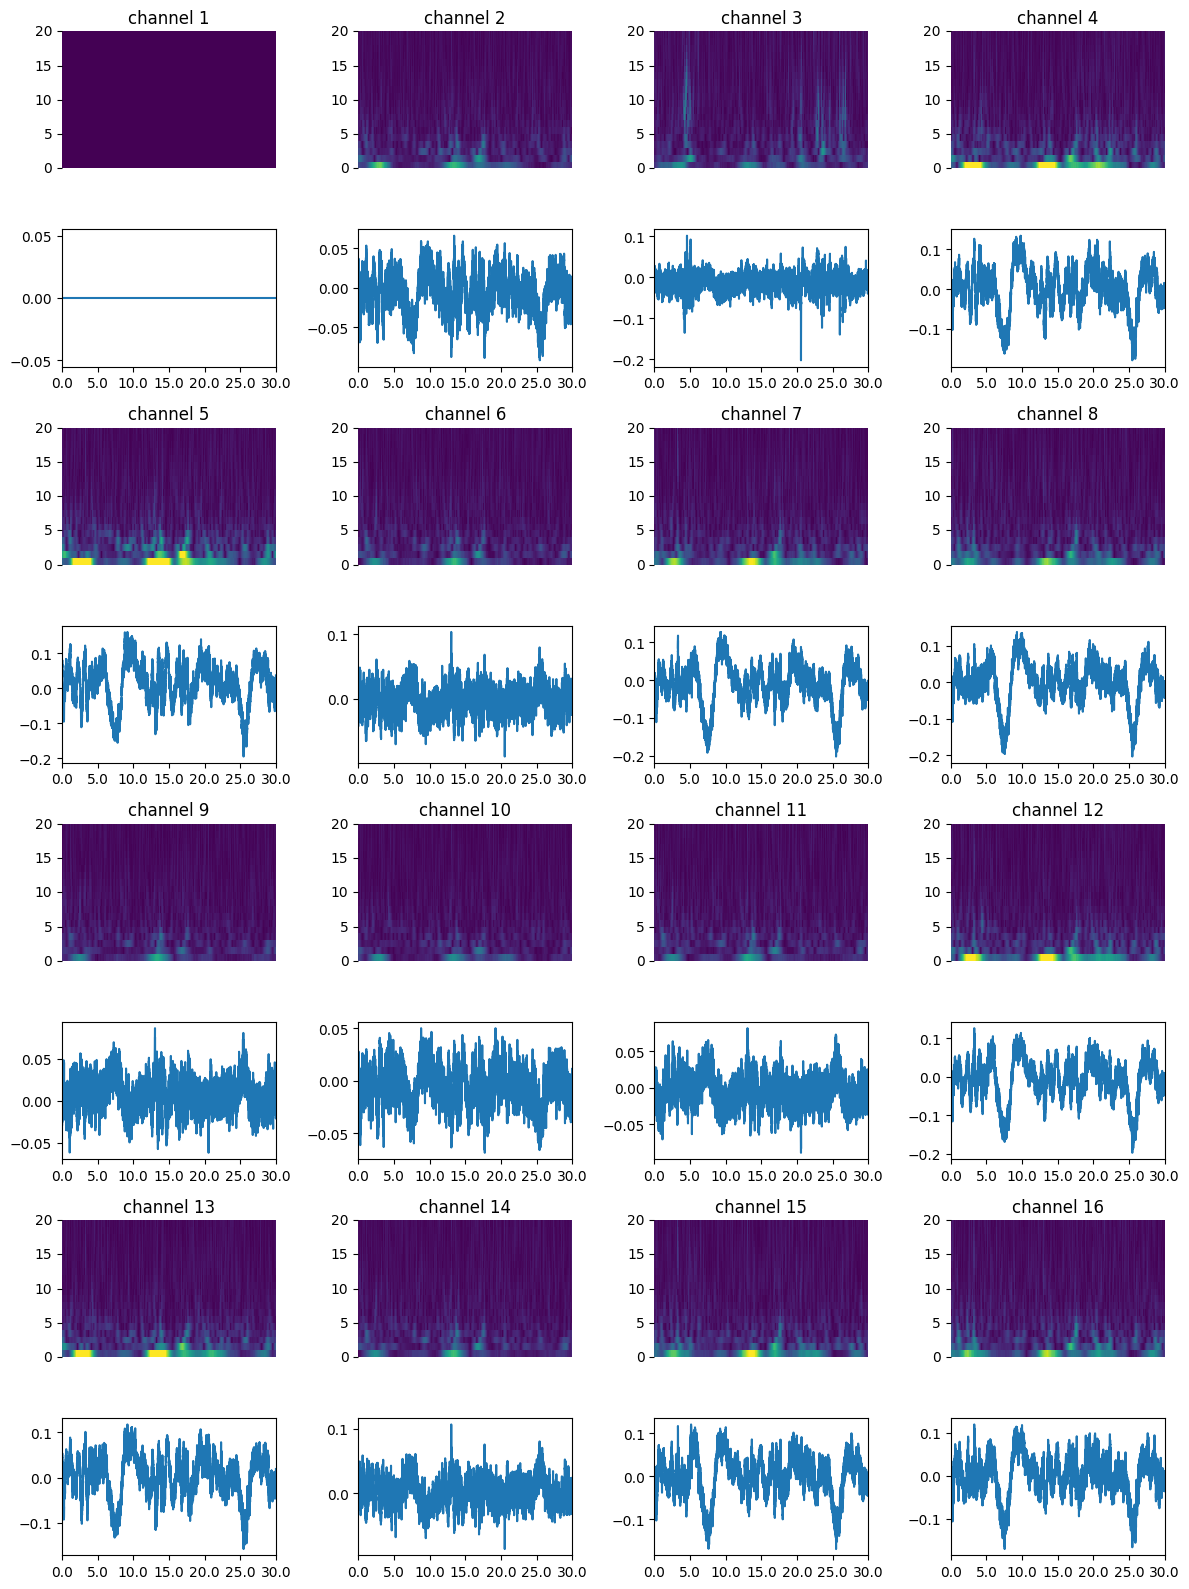

In [17]:
plt.figure(figsize=(12, 16))
t_max = 30000
t_label = 5
vmin, vmax = 0, 0.1

for channel in range(len(lfp_subtracted.T)):
    row = channel // 4
    col = channel % 4
    plt.subplot(8, 4, row*8+col+1)
    sns.heatmap(cwtmatr_subtracted[:, channel, :t_max], cmap="viridis", cbar=False, xticklabels=False, vmin=vmin, vmax=vmax)
    plt.title(f"channel {channel+1}")
    plt.ylim(0, 60)
    plt.yticks(np.arange(0, 61, 10), np.arange(0, 61, 10))

    plt.subplot(8, 4, row*8+col+5)
    plt.plot(lfp_subtracted[:t_max, channel])
    plt.xlim(0, t_max)
    plt.xticks(np.arange(0, t_max+1, t_label*fs), np.arange(0, t_max/fs+1, t_label))

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 16))
# 0~20 Hz
for channel in range(len(lfp_subtracted.T)):
    row = channel // 4
    col = channel % 4
    plt.subplot(8, 4, row*8+col+1)
    sns.heatmap(cwtmatr_subtracted[:, channel, :t_max], cmap="viridis", cbar=False, xticklabels=False, vmin=vmin, vmax=vmax)
    plt.title(f"channel {channel+1}")
    plt.ylim(0, 20)
    plt.yticks(np.arange(0, 21, 5), np.arange(0, 21, 5))

    plt.subplot(8, 4, row*8+col+5)
    plt.plot(lfp_subtracted[:t_max, channel])
    plt.xlim(0, t_max)
    plt.xticks(np.arange(0, t_max+1, t_label*fs), np.arange(0, t_max/fs+1, t_label))

plt.tight_layout()
plt.show()

In [18]:
path_plx = "../data/22q_del_WT_raw_data/241117-2-2_ID241(22qdel)_M1 (-1.0mm, 1.0mm, 0.75mm).plx"

plx = neo.io.PlexonIO(filename=path_plx)

Parsing signal channels: 100%|██████████| 128/128 [00:00<?, ?it/s]
Parsing spike channels: 0it [00:00, ?it/s]
Parsing event channels: 100%|██████████| 43/43 [00:00<?, ?it/s]


In [19]:
# read data
data = plx.read()

In [20]:
# analogsignals
# 0: AI, LFP?, Noise?
# 1: LFP
# 2: spikes
for analogsignals in data[0].segments[0].analogsignals:
    display(analogsignals)

AnalogSignal with 2 channels of length 307883; units dimensionless; datatype float32
name: 'AI-Auxiliary Input'
annotations: {'stream_id': 'AI'}
sampling rate: 1000.0 Hz
time: 0.0 s to 307.883 s

AnalogSignal with 16 channels of length 307904; units dimensionless; datatype float32
name: 'FPl-Low Pass Filtered'
annotations: {'stream_id': 'FP'}
sampling rate: 1000.0 Hz
time: 0.0 s to 307.904 s

AnalogSignal with 16 channels of length 12316176; units dimensionless; datatype float32
name: 'SPKC'
annotations: {'stream_id': 'SPKC'}
sampling rate: 40000.0 Hz
time: 0.0 s to 307.9044 s

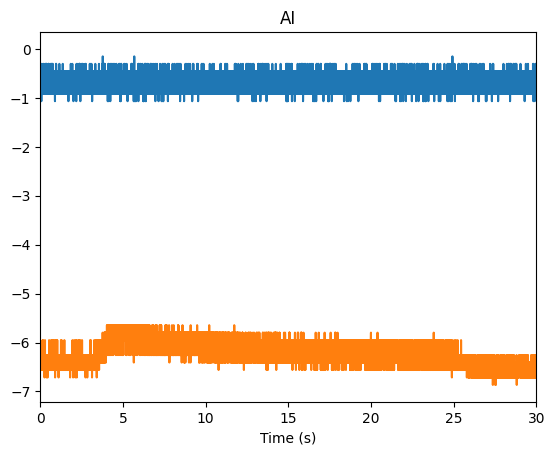

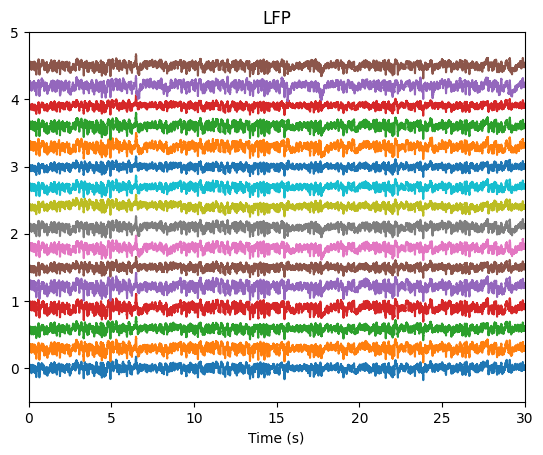

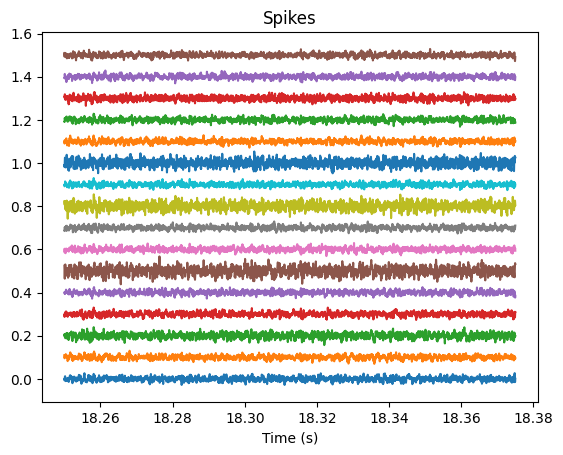

In [21]:
# get spikes, LFP, AI?
ai = data[0].segments[0].analogsignals[0]
lfp = data[0].segments[0].analogsignals[1]
spikes = data[0].segments[0].analogsignals[2]

# plot AI
plt.figure()
for i, ai_channel in enumerate(ai.T):
    plt.plot(ai.times, ai_channel)
plt.title("AI")
plt.xlabel("Time (s)")
plt.xlim(0, 30)
plt.show()

# plot LFP
plt.figure()
for i, lfp_channel in enumerate(lfp.T):
    plt.plot(lfp.times, lfp_channel + i * 0.3)
plt.title("LFP")
plt.xlabel("Time (s)")
plt.xlim(0, 30)
plt.ylim(-0.5, 5.0)
plt.show()

# plot spikes
idx_start = 730000
idx_length = 5000

plt.figure()
for i, spikes_channel in enumerate(spikes.T):
    plt.plot(spikes.times[idx_start:idx_start+idx_length], spikes_channel[idx_start:idx_start+idx_length] + i * 0.1)
plt.title("Spikes")
plt.xlabel("Time (s)")
plt.show()

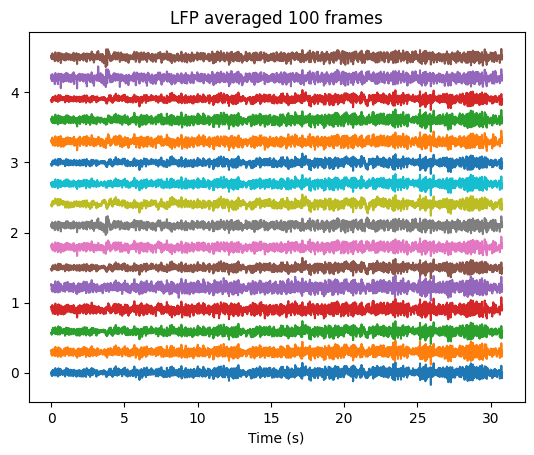

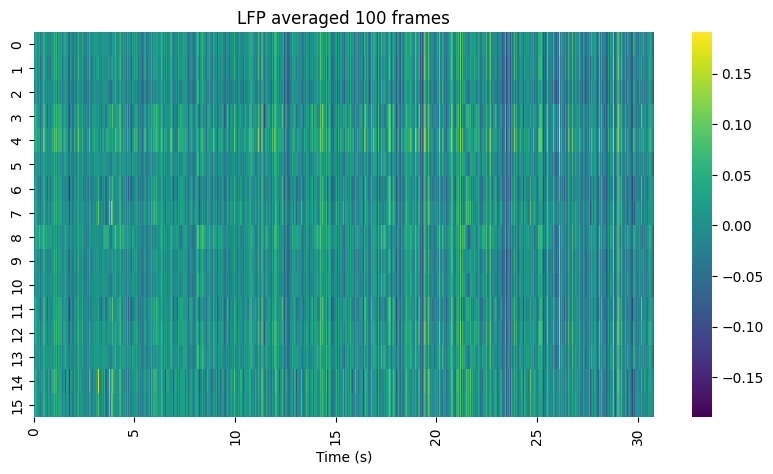

In [22]:
# 100 frame average
mean_duration = 100

lfp_mean = []

for i in range(len(lfp) // mean_duration):
    lfp_mean.append(np.mean(lfp[i*mean_duration:(i+1)*mean_duration], axis=0))

lfp_mean = np.array(lfp_mean)

# plot LFP
plt.figure()
for i, lfp_channel in enumerate(lfp_mean.T):
    plt.plot(lfp_channel + i * 0.3)
plt.title(f"LFP averaged {mean_duration} frames")
plt.xlabel("Time (s)")
plt.xticks(np.arange(0, 35*mean_duration, 5*mean_duration), np.arange(0, 35, 5))
plt.show()

# heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(lfp_mean.T, cmap="viridis")
plt.title(f"LFP averaged {mean_duration} frames")
plt.xlabel("Time (s)")
plt.xticks(np.arange(0, 35*mean_duration, 5*mean_duration), np.arange(0, 35, 5))
plt.show()

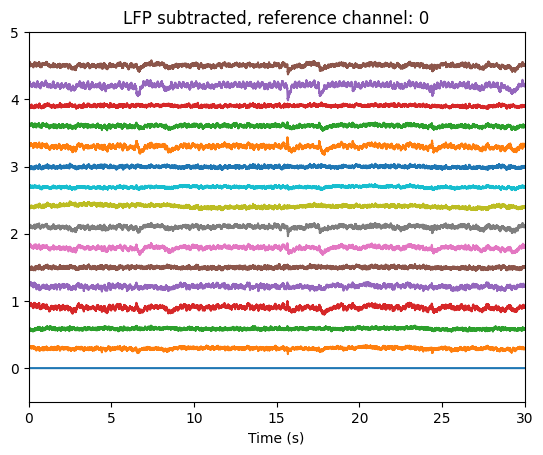

In [23]:
# substract with reference channel
channel_ref = 0

lfp_subtracted = lfp - lfp[:, channel_ref]

# plot LFP
plt.figure()
for i, lfp_channel in enumerate(lfp_subtracted.T):
    plt.plot(lfp.times, lfp_channel + i * 0.3)
plt.title(f"LFP subtracted, reference channel: {channel_ref}")
plt.xlabel("Time (s)")
plt.xlim(0, 30)
plt.ylim(-0.5, 5.0)
plt.show()

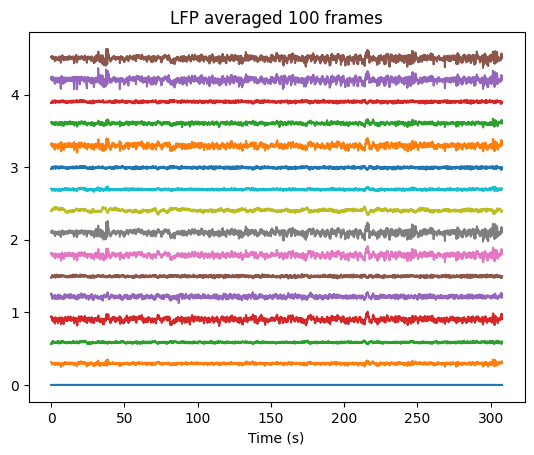

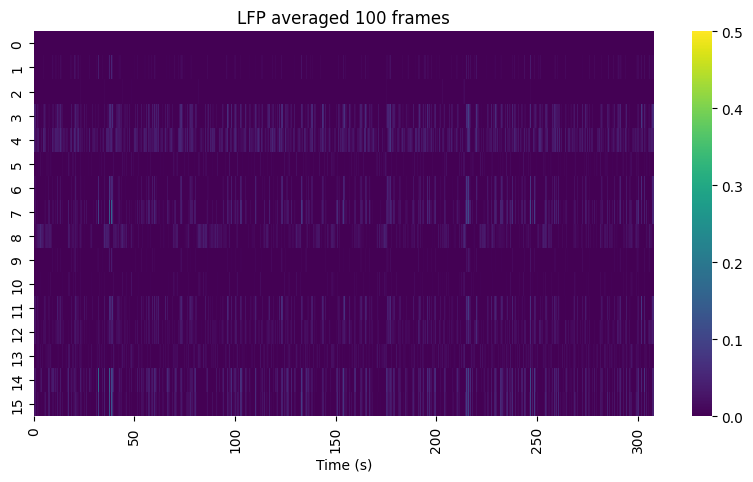

In [24]:
# 100 frame average
mean_duration = 100

lfp_mean = []

for i in range(len(lfp_subtracted) // mean_duration):
    lfp_mean.append(np.mean(lfp_subtracted[i*mean_duration:(i+1)*mean_duration], axis=0))

lfp_mean = np.array(lfp_mean)

# plot LFP
plt.figure()
for i, lfp_channel in enumerate(lfp_mean.T):
    plt.plot(lfp_channel + i * 0.3)
plt.title(f"LFP averaged {mean_duration} frames")
plt.xlabel("Time (s)")
plt.xticks(np.arange(0, 35*mean_duration, 5*mean_duration), np.arange(0, 350, 50))
plt.show()

# heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(lfp_mean.T, cmap="viridis", vmin=0, vmax=0.5)
plt.title(f"LFP averaged {mean_duration} frames")
plt.xlabel("Time (s)")
plt.xticks(np.arange(0, 35*mean_duration, 5*mean_duration), np.arange(0, 350, 50))
plt.show()

## Wavelet transform

In [25]:
fs = 1000
wavelet = "cmor1.5-1.0"

# 解析したい周波数帯
frequencies = np.arange(1, 61, 1)  # 1Hzから60Hzまで1Hz刻み
# 各周波数に対応するスケール値を計算　周波数をそのままは使えない！！！！
scales = pywt.frequency2scale(wavelet, frequencies) * fs
cwtmatr, freq = pywt.cwt(lfp.T, scales, wavelet, sampling_period=1/fs)
cwtmatr = np.abs(cwtmatr)

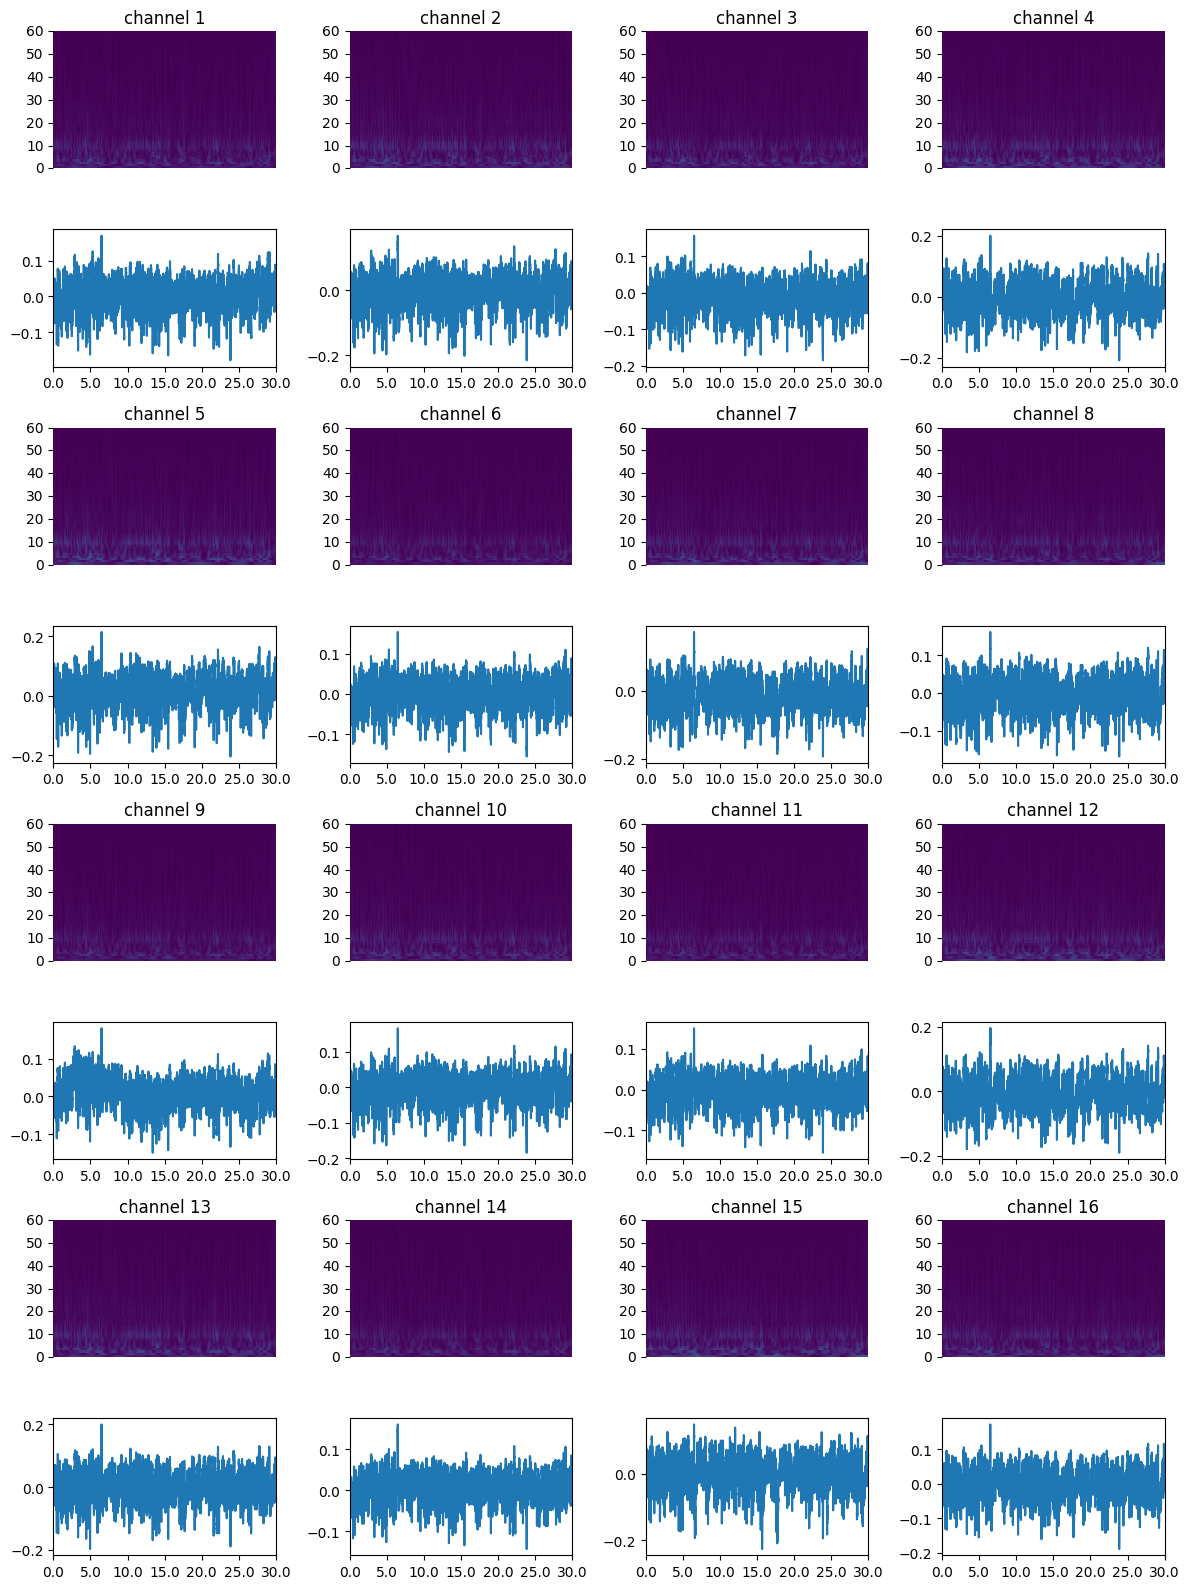

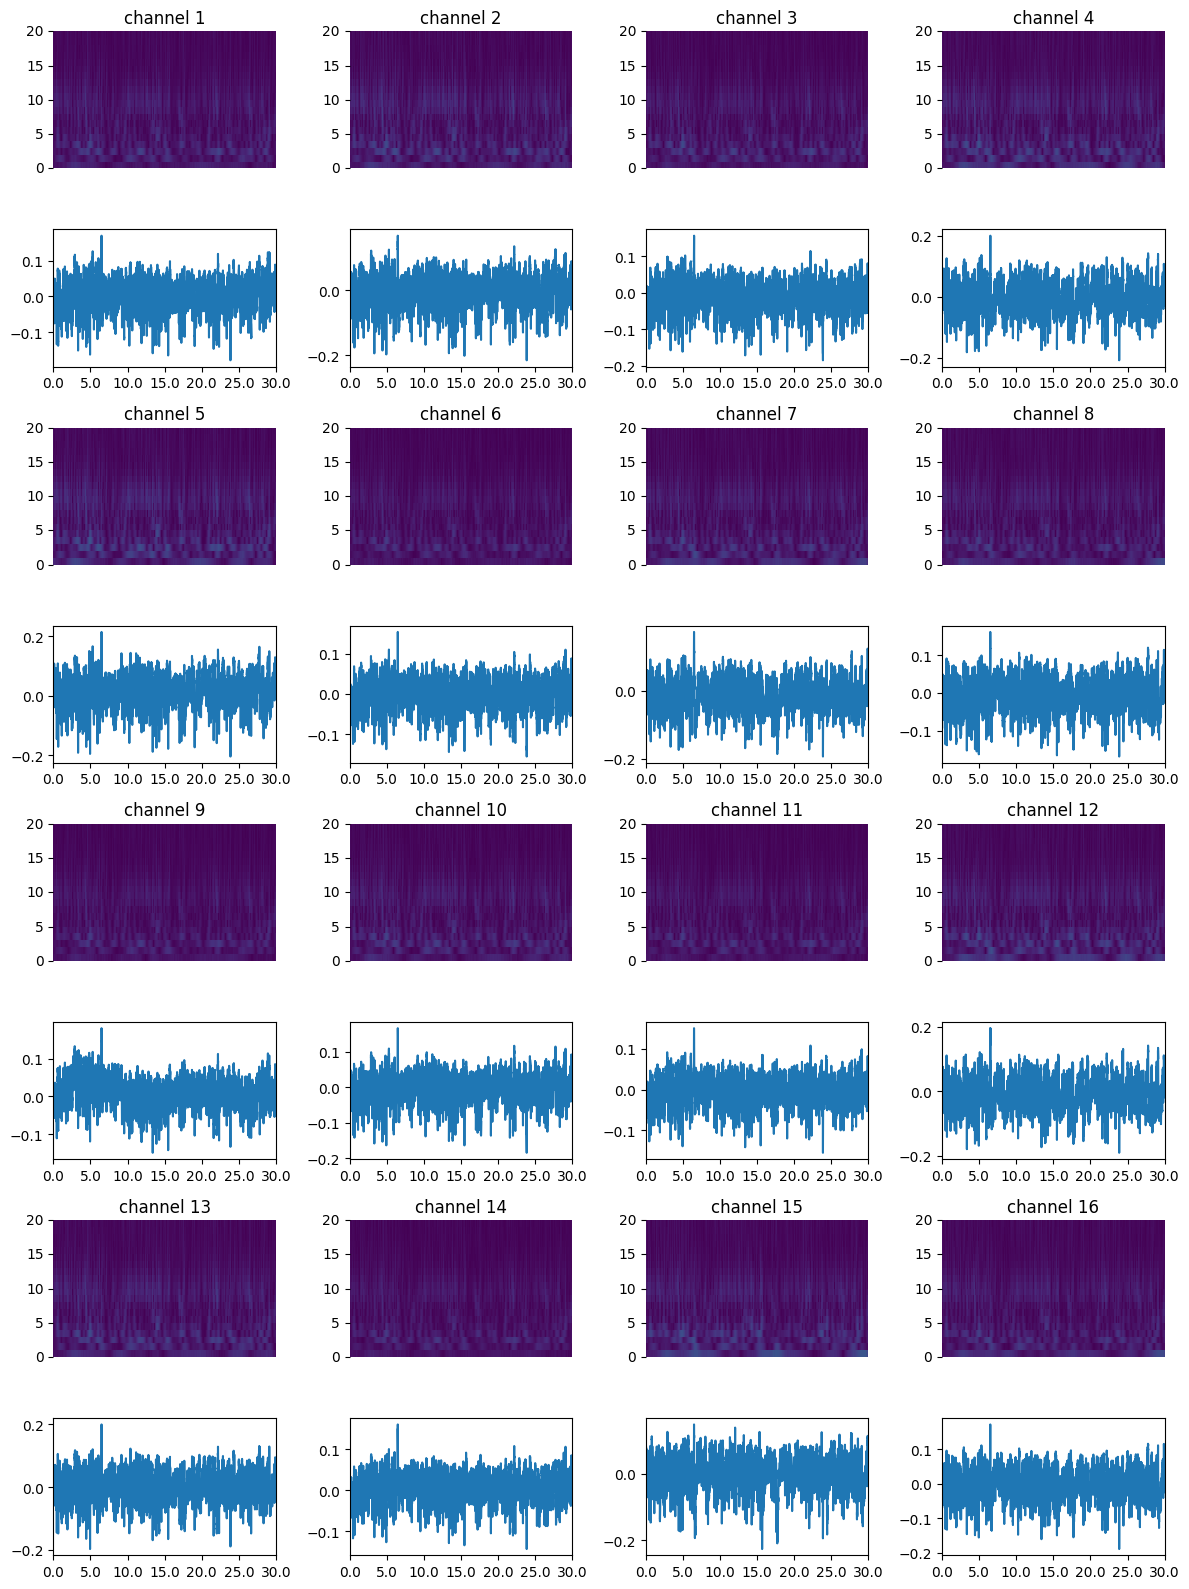

In [26]:
plt.figure(figsize=(12, 16))
t_max = 30000
t_label = 5
vmin, vmax = 0, 2

for channel in range(len(lfp.T)):
    row = channel // 4
    col = channel % 4
    plt.subplot(8, 4, row*8+col+1)
    sns.heatmap(cwtmatr[:, channel, :t_max], cmap="viridis", cbar=False, xticklabels=False, vmin=vmin, vmax=vmax)
    plt.title(f"channel {channel+1}")
    plt.ylim(0, 60)
    plt.yticks(np.arange(0, 61, 10), np.arange(0, 61, 10))

    plt.subplot(8, 4, row*8+col+5)
    plt.plot(lfp[:t_max, channel])
    plt.xlim(0, t_max)
    plt.xticks(np.arange(0, t_max+1, t_label*fs), np.arange(0, t_max/fs+1, t_label))

plt.tight_layout()
plt.show()

# 0~20 Hz
plt.figure(figsize=(12, 16))
t_max = 30000
t_label = 5

for channel in range(len(lfp.T)):
    row = channel // 4
    col = channel % 4
    plt.subplot(8, 4, row*8+col+1)
    sns.heatmap(cwtmatr[:, channel, :t_max], cmap="viridis", cbar=False, xticklabels=False, vmin=vmin, vmax=vmax)
    plt.title(f"channel {channel+1}")
    plt.ylim(0, 20)
    plt.yticks(np.arange(0, 21, 5), np.arange(0, 21, 5))

    plt.subplot(8, 4, row*8+col+5)
    plt.plot(lfp[:t_max, channel])
    plt.xlim(0, t_max)
    plt.xticks(np.arange(0, t_max+1, t_label*fs), np.arange(0, t_max/fs+1, t_label))

plt.tight_layout()
plt.show()

In [27]:
fs = 1000
wavelet = "cmor1.5-1.0"

# 解析したい周波数帯
frequencies = np.arange(1, 61, 1)  # 1Hzから60Hzまで1Hz刻み
# 各周波数に対応するスケール値を計算　周波数をそのままは使えない！！！！
scales = pywt.frequency2scale(wavelet, frequencies) * fs
cwtmatr_subtracted, freq = pywt.cwt(lfp_subtracted.T, scales, wavelet, sampling_period=1/fs)
cwtmatr_subtracted = np.abs(cwtmatr_subtracted)

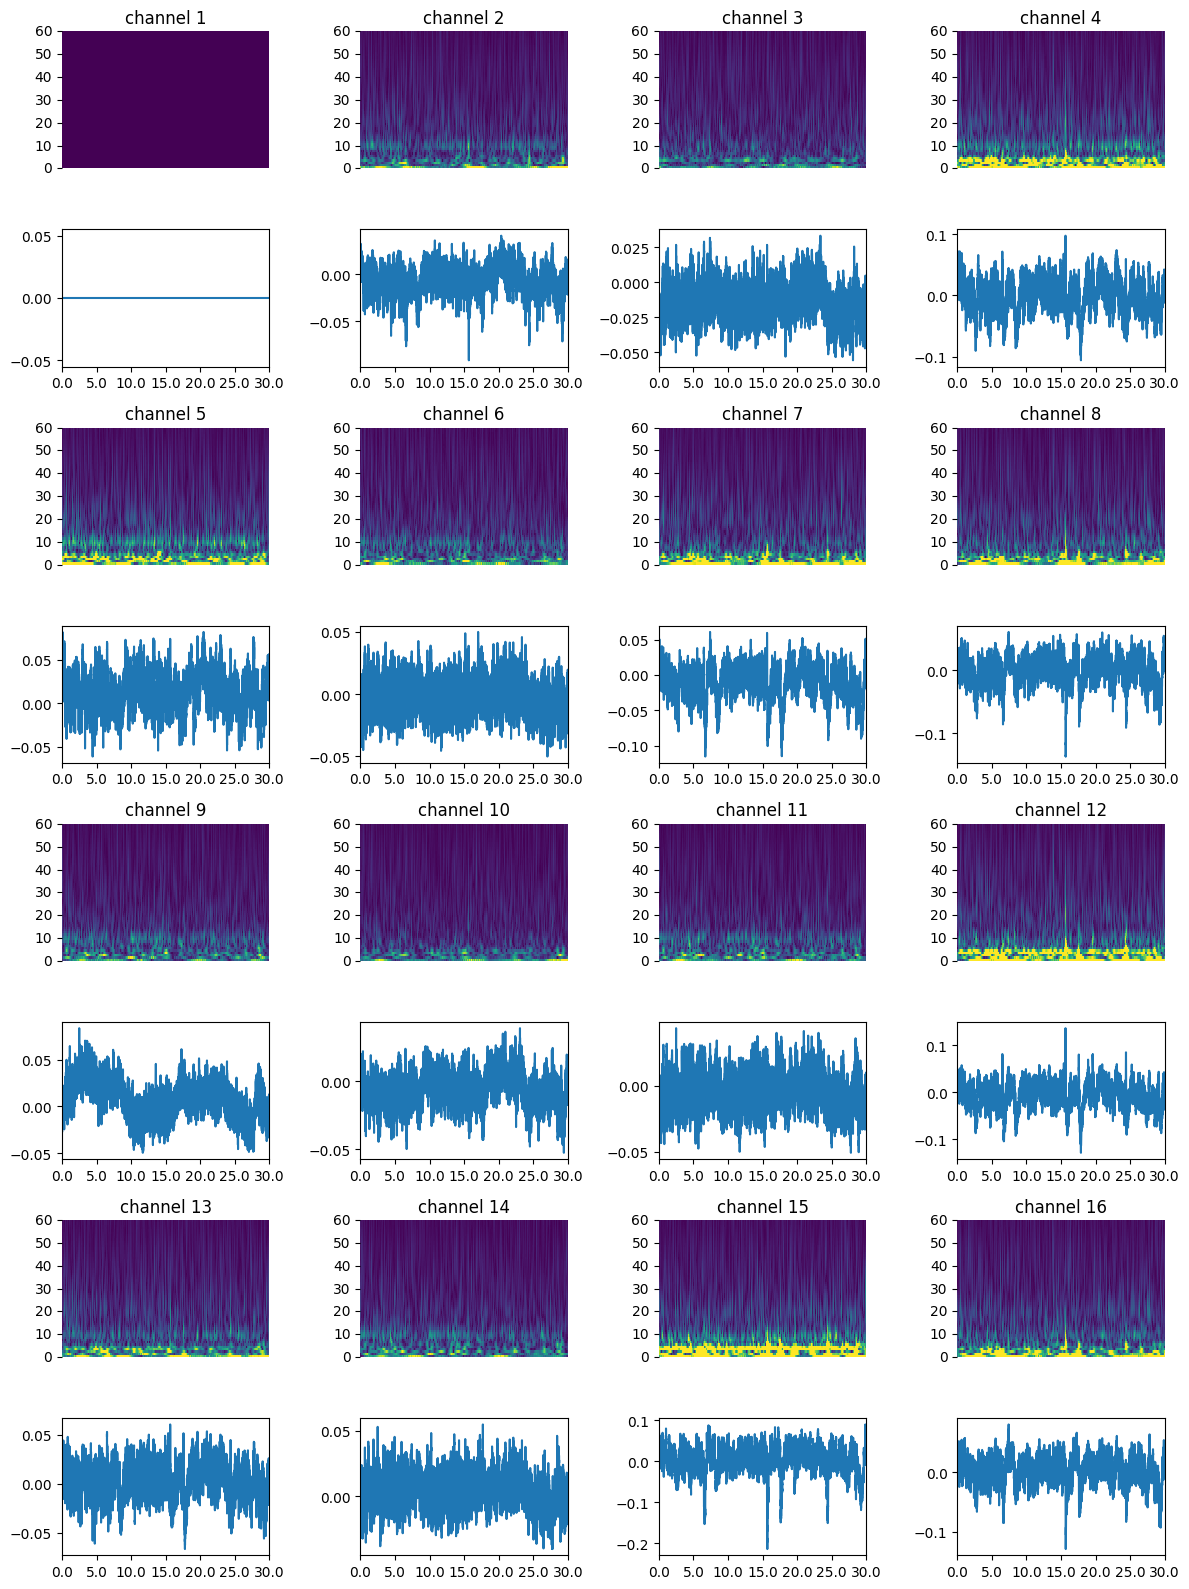

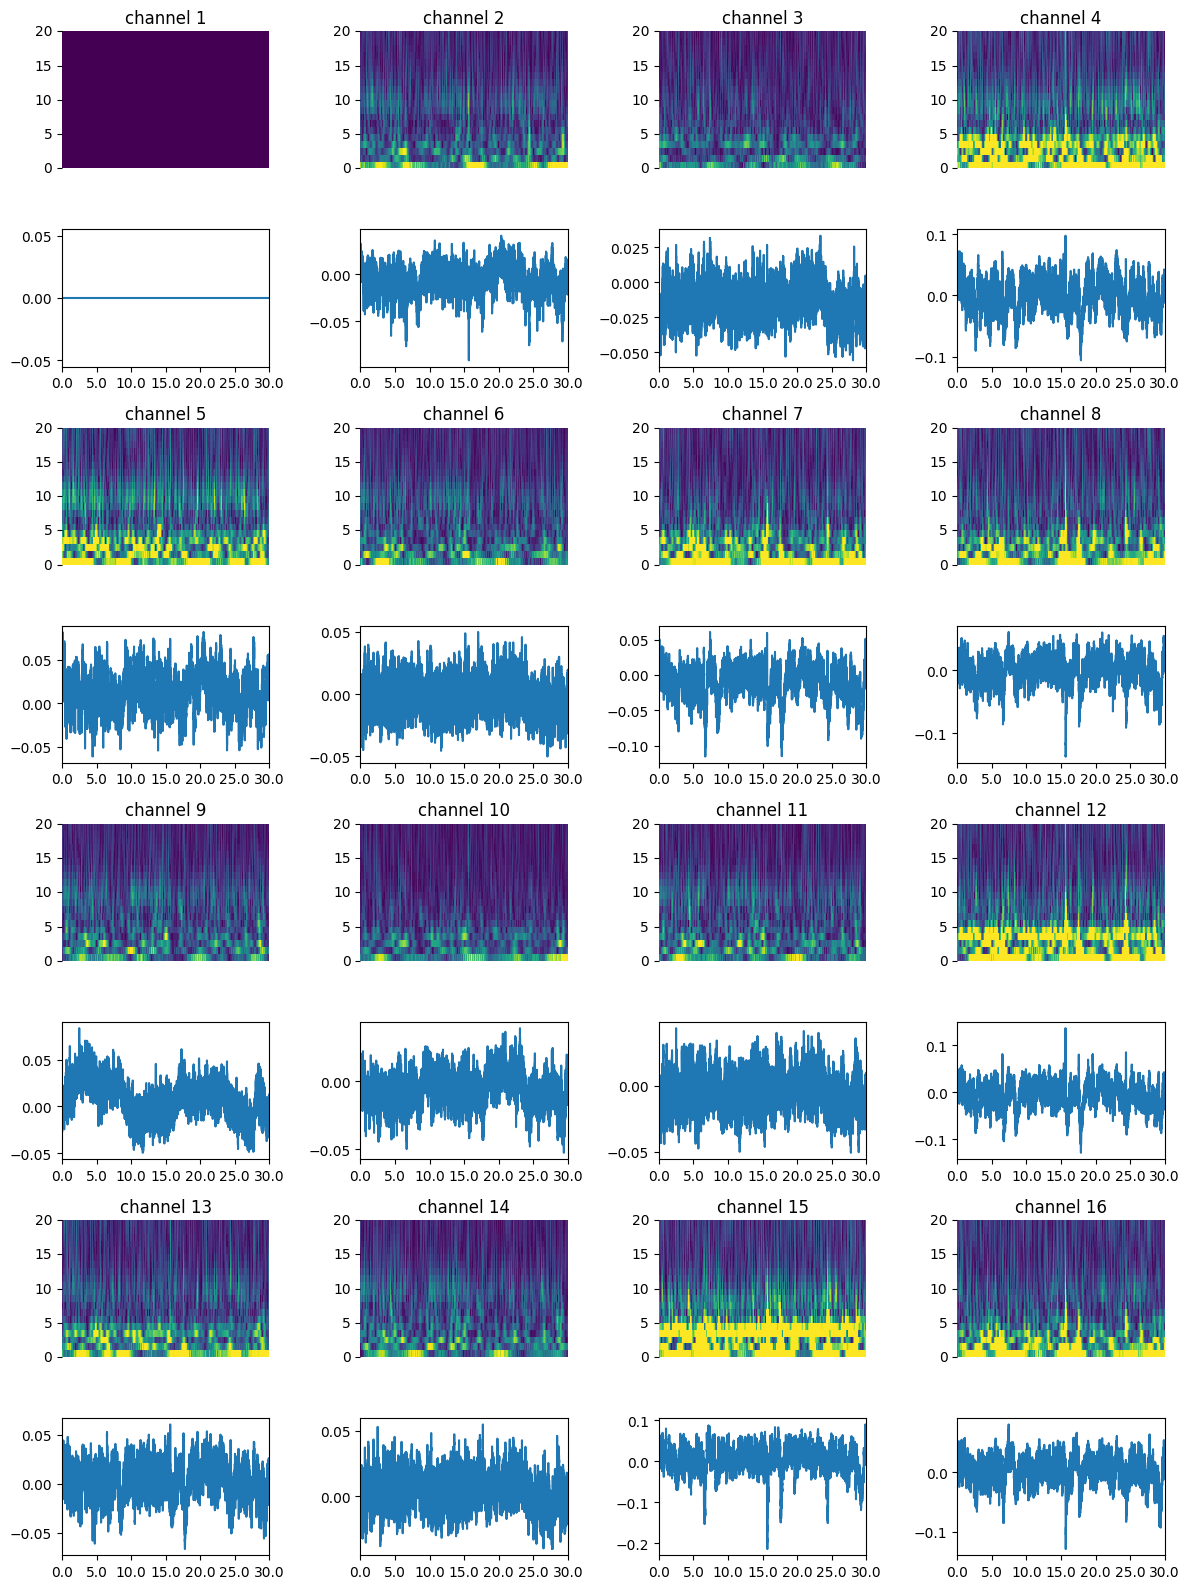

In [28]:
plt.figure(figsize=(12, 16))
t_max = 30000
t_label = 5
vmin, vmax = 0, 0.1

for channel in range(len(lfp_subtracted.T)):
    row = channel // 4
    col = channel % 4
    plt.subplot(8, 4, row*8+col+1)
    sns.heatmap(cwtmatr_subtracted[:, channel, :t_max], cmap="viridis", cbar=False, xticklabels=False, vmin=vmin, vmax=vmax)
    plt.title(f"channel {channel+1}")
    plt.ylim(0, 60)
    plt.yticks(np.arange(0, 61, 10), np.arange(0, 61, 10))

    plt.subplot(8, 4, row*8+col+5)
    plt.plot(lfp_subtracted[:t_max, channel])
    plt.xlim(0, t_max)
    plt.xticks(np.arange(0, t_max+1, t_label*fs), np.arange(0, t_max/fs+1, t_label))

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 16))
# 0~20 Hz
for channel in range(len(lfp_subtracted.T)):
    row = channel // 4
    col = channel % 4
    plt.subplot(8, 4, row*8+col+1)
    sns.heatmap(cwtmatr_subtracted[:, channel, :t_max], cmap="viridis", cbar=False, xticklabels=False, vmin=vmin, vmax=vmax)
    plt.title(f"channel {channel+1}")
    plt.ylim(0, 20)
    plt.yticks(np.arange(0, 21, 5), np.arange(0, 21, 5))

    plt.subplot(8, 4, row*8+col+5)
    plt.plot(lfp_subtracted[:t_max, channel])
    plt.xlim(0, t_max)
    plt.xticks(np.arange(0, t_max+1, t_label*fs), np.arange(0, t_max/fs+1, t_label))

plt.tight_layout()
plt.show()